# Analyse Comparative Exhaustive : Solveur MCMC Higher-Order pour 3-SAT

Ce notebook implémente, évalue et analyse les performances d'un solveur MCMC **Higher-Order (HO)** par rapport à des solveurs CDCL (Glucose4), Max-SAT exacts (RC2), et WalkSAT pur (Random-start).

## 1. Principes Algorithmiques & Mathématiques
Le solveur MCMC Higher-Order résout le problème 3-SAT en se basant sur la physique statistique de la percolation :
1. **Graphe Signé Étendu** : Représentation unifiée des clauses de taille 1, 2 et 3 à l'aide de poids signés et de variables auxiliaires.
2. **Double Transfert d'Énergie** : Optimisation linéaire (LP) pour maximiser le transfert de poids des arêtes vers les triangles afin de capturer l'ordre supérieur.
3. **Séparation de la température (`beta_T_factor`)** : Réduction par un facteur 10 du gel probabiliste des arêtes/triangles incidentes à la variable fantôme $T$ (champ externe). Cela évite le piège de la percolation complète ($K_T$) et préserve la mobilité des spins originaux.
4. **Recherche Locale Réduite** : Identification des clusters flippables originaux et résolution locale du problème de spin-flip réduit via WalkSAT réduit (ou énumération exacte).
5. **Warm-Start** : Initialisation de la recherche locale WalkSAT à partir de la configuration optimale fournie par MCMC HO.

Ce notebook exécute l'analyse sur des benchmarks réels industriels (SAT Competition), académiques (SATLIB) et locaux (Circuit Miters).

In [1]:
# Installation des bibliothèques nécessaires
!pip install -q python-sat pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## 2. Code Source du Solveur MCMC Higher-Order
Le code ci-dessous correspond à l'implémentation complète du solveur (chargé dynamiquement depuis `mcmc_higher_order.py`).

In [2]:
import time
import random
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
from scipy.optimize import linprog

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

def recursive_unit_propagation_and_reductions(num_vars, clauses, active_vars=None, verbose=False):
    """
    Recursively applies unit propagation and pure literal elimination.
    """
    fixed_literals = {}
    active_clauses = [list(c) for c in clauses]
    if active_vars is None:
        active_vars = set(range(1, num_vars + 1))
    else:
        active_vars = set(active_vars)
    fixed_empty_clauses = 0
    
    changed = True
    while changed:
        changed = False
        
        # Count empty clauses
        empty_clauses = sum(1 for c in active_clauses if len(c) == 0)
        if empty_clauses:
            fixed_empty_clauses += empty_clauses
            active_clauses = [c for c in active_clauses if len(c) > 0]
        
        # 1. Unit propagation
        unit_counts = {}
        for c in active_clauses:
            if len(c) == 1:
                lit = c[0]
                unit_counts[lit] = unit_counts.get(lit, 0) + 1
                
        if unit_counts:
            var_unit_info = {}
            for lit, count in unit_counts.items():
                var = abs(lit)
                pol = 1 if lit > 0 else -1
                if var not in var_unit_info:
                    var_unit_info[var] = {1: 0, -1: 0}
                var_unit_info[var][pol] = count
                
            for var in sorted(list(var_unit_info.keys())):
                info = var_unit_info[var]
                pos_units = info[1]
                neg_units = info[-1]
                
                if pos_units >= neg_units:
                    l_val = 1
                    m = pos_units
                    opp_units = neg_units
                else:
                    l_val = -1
                    m = neg_units
                    opp_units = pos_units
                    
                opp_clauses_count = 0
                for c in active_clauses:
                    if len(c) >= 2:
                        for lit in c:
                            if abs(lit) == var:
                                pol = 1 if lit > 0 else -1
                                if pol != l_val:
                                    opp_clauses_count += 1
                                    break
                                    
                k = opp_clauses_count + opp_units
                
                if m >= k:
                    fixed_literals[var] = l_val
                    active_vars.remove(var)
                    
                    new_active_clauses = []
                    for c in active_clauses:
                        satisfied = False
                        for lit in c:
                            if abs(lit) == var:
                                pol = 1 if lit > 0 else -1
                                if pol == l_val:
                                    satisfied = True
                                    break
                        if not satisfied:
                            new_clause = [lit for lit in c if abs(lit) != var]
                            new_active_clauses.append(new_clause)
                    active_clauses = new_active_clauses
                    changed = True
                    break
            if changed:
                continue
                
        # 2. Pure literal elimination
        pos_counts = {v: 0 for v in active_vars}
        neg_counts = {v: 0 for v in active_vars}
        for c in active_clauses:
            for lit in c:
                var = abs(lit)
                if var in active_vars:
                    if lit > 0:
                        pos_counts[var] += 1
                    else:
                        neg_counts[var] += 1
                        
        pure_vars = []
        for var in list(active_vars):
            pos = pos_counts[var]
            neg = neg_counts[var]
            if pos > 0 and neg == 0:
                pure_vars.append((var, 1))
            elif neg > 0 and pos == 0:
                pure_vars.append((var, -1))
            elif pos == 0 and neg == 0:
                pure_vars.append((var, 1))
                
        if pure_vars:
            changed = True
            for var, val in pure_vars:
                fixed_literals[var] = val
                active_vars.remove(var)
            
            new_active_clauses = []
            for c in active_clauses:
                satisfied = False
                for lit in c:
                    var = abs(lit)
                    val = 1 if lit > 0 else -1
                    if var in fixed_literals and fixed_literals[var] == val:
                        satisfied = True
                        break
                if not satisfied:
                    new_clause = [lit for lit in c if abs(lit) in active_vars]
                    new_active_clauses.append(new_clause)
            active_clauses = new_active_clauses
            
    return active_vars, active_clauses, fixed_literals, fixed_empty_clauses

def normalize_and_clean_clauses(clauses):
    """
    Normalizes a list of clauses by removing duplicate literals,
    removing tautologies, and sorting literals for canonical representation.
    """
    cleaned_clauses = []
    for c in clauses:
        seen = set()
        new_c = []
        tautology = False
        for lit in c:
            if lit in seen:
                continue
            if -lit in seen:
                tautology = True
                break
            seen.add(lit)
            new_c.append(lit)
        if not tautology:
            new_c.sort(key=lambda x: abs(x))
            cleaned_clauses.append(new_c)
    return cleaned_clauses

def build_signed_graph_for_3sat(num_vars, active_vars, active_clauses, u=1.0, verbose=False):
    """
    Builds the extended signed graph. Merges auxiliary nodes sharing the same canonical pair.
    Returns A (dict-of-dicts sparse representation), var_to_idx, clause3_list, clause_to_merged_idx, total_nodes.
    """
    var_list = sorted(list(active_vars))
    var_to_idx = {v: i + 1 for i, v in enumerate(var_list)}
    N_red = len(var_list)
    
    clause3_list = []
    for c in active_clauses:
        if len(c) == 3:
            v1, v2, v3 = abs(c[0]), abs(c[1]), abs(c[2])
            idx1, idx2, idx3 = var_to_idx[v1], var_to_idx[v2], var_to_idx[v3]
            pol1 = 1 if c[0] > 0 else -1
            pol2 = 1 if c[1] > 0 else -1
            pol3 = 1 if c[2] > 0 else -1
            
            lits = [(idx1, pol1), (idx2, pol2), (idx3, pol3)]
            lits.sort(key=lambda x: x[0])
            canonical_pair = (lits[0][0], lits[0][1], lits[1][0], lits[1][1])
            
            clause3_list.append({
                'idx': [idx1, idx2, idx3],
                'pol': [pol1, pol2, pol3],
                'canonical_pair': canonical_pair
            })
            
    n_clause3 = len(clause3_list)
    adj = {i: [] for i in range(n_clause3)}
    for i in range(n_clause3):
        for j in range(i + 1, n_clause3):
            if clause3_list[i]['canonical_pair'] == clause3_list[j]['canonical_pair']:
                adj[i].append(j)
                adj[j].append(i)
                
    visited = [False] * n_clause3
    components = []
    for i in range(n_clause3):
        if not visited[i]:
            comp = []
            queue = [i]
            visited[i] = True
            while queue:
                curr = queue.pop(0)
                comp.append(curr)
                for neighbor in adj[curr]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)
            components.append(comp)
            
    clause_to_merged_idx = {}
    n_merged_nodes = len(components)
    for comp_idx, comp in enumerate(components):
        merged_node = N_red + 1 + comp_idx
        for clause_idx in comp:
            clause_to_merged_idx[clause_idx] = merged_node
            
    edges = []
    clause3_counter = 0
    for c in active_clauses:
        if len(c) == 1:
            lit = c[0]
            v = abs(lit)
            idx = var_to_idx[v]
            pol = 1 if lit > 0 else -1
            edges.append((idx, 0, u, pol))
        elif len(c) == 2:
            v1, v2 = abs(c[0]), abs(c[1])
            idx1, idx2 = var_to_idx[v1], var_to_idx[v2]
            pol1 = 1 if c[0] > 0 else -1
            pol2 = 1 if c[1] > 0 else -1
            edges.append((idx1, 0, u / 2.0, pol1))
            edges.append((idx2, 0, u / 2.0, pol2))
            edges.append((idx1, idx2, u / 2.0, -pol1 * pol2))
        elif len(c) == 3:
            info = clause3_list[clause3_counter]
            idx1, idx2, idx3 = info['idx']
            pol1, pol2, pol3 = info['pol']
            s = clause_to_merged_idx[clause3_counter]
            
            edges.append((idx1, 0, u / 2.0, pol1))
            edges.append((idx2, 0, u / 2.0, pol2))
            edges.append((idx3, 0, u / 2.0, pol3))
            edges.append((s, idx1, u / 2.0, pol1))
            edges.append((s, idx2, u / 2.0, pol2))
            edges.append((s, idx3, u / 2.0, pol3))
            edges.append((s, 0, u / 2.0, -1))
            edges.append((idx1, idx2, u / 2.0, -pol1 * pol2))
            edges.append((idx2, idx3, u / 2.0, -pol2 * pol3))
            edges.append((idx1, idx3, u / 2.0, -pol1 * pol3))
            clause3_counter += 1
            
    total_nodes = N_red + 1 + n_merged_nodes
    # Initialize A as a sparse dict-of-dicts pre-populated with empty dicts for each node
    A = {i: {} for i in range(total_nodes)}
    for u_node, v_node, weight, sign in edges:
        val = sign * weight
        A[u_node][v_node] = A[u_node].get(v_node, 0.0) + val
        A[v_node][u_node] = A[v_node].get(u_node, 0.0) + val
    return A, var_to_idx, clause3_list, clause_to_merged_idx, total_nodes

def find_triangles(A, total_nodes):
    """
    Finds all unique triangles (i < j < k) in the graph with non-zero edge weights.
    """
    adj_sets = {}
    for u in range(total_nodes):
        adj_sets[u] = {v for v, w in A[u].items() if abs(w) > 1e-9}
        
    triangles = []
    for u in range(total_nodes):
        neighbors_u = adj_sets[u]
        # Only check neighbors v > u
        neighbors_u_gt = [v for v in neighbors_u if v > u]
        for v in neighbors_u_gt:
            common = neighbors_u.intersection(adj_sets[v])
            for w in common:
                if w > v:
                    triangles.append((u, v, w))
    return triangles

def transfer_weights_to_triangles(A, triangles, total_nodes):
    """
    Formulates and solves the LP weight transfer to maximize triangle weights.
    Uses sparse matrix for the constraints to prevent memory issues.
    """
    edges_list = []
    edge_to_idx = {}
    for u in range(total_nodes):
        for v in A[u]:
            if v > u and abs(A[u][v]) > 1e-9:
                idx = len(edges_list)
                edges_list.append((u, v))
                edge_to_idx[(u, v)] = idx
                
    Ne = len(edges_list)
    Nt = len(triangles)
    W = np.array([abs(A[u][v]) for u, v in edges_list], dtype=np.float64)
    
    if Nt == 0:
        return np.zeros(0), W, edges_list, edge_to_idx
        
    rows = []
    cols = []
    data = []
    for t_idx, (i, j, k) in enumerate(triangles):
        e1 = (i, j) if (i, j) in edge_to_idx else (j, i)
        e2 = (j, k) if (j, k) in edge_to_idx else (k, j)
        e3 = (i, k) if (i, k) in edge_to_idx else (k, i)
        
        rows.extend([edge_to_idx[e1], edge_to_idx[e2], edge_to_idx[e3]])
        cols.extend([t_idx, t_idx, t_idx])
        data.extend([1.0, 1.0, 1.0])
        
    M_sparse = scipy.sparse.coo_matrix((data, (rows, cols)), shape=(Ne, Nt))
    
    c = -np.ones(Nt, dtype=np.float64)
    res = linprog(c, A_ub=M_sparse, b_ub=W, bounds=(0, None), method='highs')
    if res.success:
        omega = res.x
    else:
        omega = np.zeros(Nt, dtype=np.float64)
        
    rho = np.maximum(0.0, W - M_sparse.dot(omega))
    return omega, rho, edges_list, edge_to_idx

def optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx):
    """
    Optimizes each auxiliary spin (or merged certificate) to minimize extended energy.
    """
    aux_to_clauses = {}
    for c_idx, info in enumerate(clause3_list):
        aux_node = clause_to_merged_idx[c_idx]
        if aux_node not in aux_to_clauses:
            aux_to_clauses[aux_node] = []
        aux_to_clauses[aux_node].append(info)
        
    for aux_node, infos in aux_to_clauses.items():
        total_val = 0.0
        for info in infos:
            idx1, idx2, idx3 = info['idx']
            pol1, pol2, pol3 = info['pol']
            
            L1 = pol1 * sigma[idx1]
            L2 = pol2 * sigma[idx2]
            L3 = pol3 * sigma[idx3]
            
            total_val += (1.0 - L1 - L2 - L3)
            
        if total_val >= 0.0:
            sigma[aux_node] = -1.0
        else:
            sigma[aux_node] = 1.0

def find_root(i, parent):
    path = []
    while parent[i] != i:
        path.append(i)
        i = parent[i]
    for node in path:
        parent[node] = i
    return i

def union(i, j, parent):
    root_i = find_root(i, parent)
    root_j = find_root(j, parent)
    if root_i != root_j:
        parent[root_i] = root_j

def build_reduced_problem(clauses, full_sigma, parent, pinned_root, var_to_idx, root_to_idx):
    """
    Reduces the original SAT clauses to constraint clauses over the flippable cluster variables.
    """
    reduced_clauses = []
    for c_idx, c in enumerate(clauses):
        trivially_satisfied = False
        forbidden = {}
        for lit in c:
            var = abs(lit)
            pol = 1 if lit > 0 else -1
            L_0 = pol * full_sigma[var]
            
            if var in var_to_idx:
                c_root = find_root(var_to_idx[var], parent)
            else:
                c_root = pinned_root
                
            if c_root == pinned_root or c_root not in root_to_idx:
                if L_0 == 1:
                    trivially_satisfied = True
                    break
                else:
                    continue
            else:
                forbidden_val = -L_0
                if c_root in forbidden:
                    if forbidden[c_root] != forbidden_val:
                        trivially_satisfied = True
                        break
                else:
                    forbidden[c_root] = forbidden_val
                    
        if not trivially_satisfied:
            reduced_clauses.append({
                'forbidden': forbidden,
                'c_idx': c_idx
            })
            
    return reduced_clauses

def solve_reduced_exhaustive(reduced_clauses, m, root_to_idx):
    """
    Finds the exact optimal flip combination by testing all 2^m configurations.
    """
    best_i = 0
    best_unsat = len(reduced_clauses)
    
    parsed = []
    for rc in reduced_clauses:
        items = []
        for r, val in rc['forbidden'].items():
            var_idx = root_to_idx[r]
            val_bin = 0 if val == 1 else 1
            items.append((var_idx, val_bin))
        parsed.append(items)
        
    for i in range(1 << m):
        unsat = 0
        for items in parsed:
            clause_unsat = True
            for var_idx, val_bin in items:
                bit = (i >> var_idx) & 1
                if bit != val_bin:
                    clause_unsat = False
                    break
            if clause_unsat:
                unsat += 1
                
        if unsat < best_unsat:
            best_unsat = unsat
            best_i = i
            if best_unsat == 0:
                break
                
    best_z = np.array([1 if not (best_i & (1 << j)) else -1 for j in range(m)], dtype=int)
    return best_z

def solve_reduced_walksat(reduced_clauses, m, root_to_idx, max_flips=None, p_noise=0.15):
    """
    WalkSAT on the cluster flip variables, targeting minimal unsatisfied reduced clauses.
    """
    z = np.ones(m, dtype=int)
    parsed = []
    cluster_to_clauses = [[] for _ in range(m)]
    
    for rc_idx, rc in enumerate(reduced_clauses):
        items = [(root_to_idx[r], val) for r, val in rc['forbidden'].items()]
        parsed.append(items)
        for var_idx, _ in items:
            cluster_to_clauses[var_idx].append(rc_idx)
            
    diff_count = np.zeros(len(reduced_clauses), dtype=int)
    unsat_list = []
    clause_to_unsat_idx = np.full(len(reduced_clauses), -1, dtype=int)
    
    for rc_idx, items in enumerate(parsed):
        c = sum(1 for var_idx, val in items if z[var_idx] != val)
        diff_count[rc_idx] = c
        if c == 0:
            clause_to_unsat_idx[rc_idx] = len(unsat_list)
            unsat_list.append(rc_idx)
            
    best_unsat = len(unsat_list)
    best_z = z.copy()
    
    if best_unsat == 0:
        return best_z
        
    if max_flips is None:
        max_flips = max(1500, 15 * best_unsat)
        
    for flip in range(max_flips):
        if not unsat_list:
            break
            
        rc_idx = random.choice(unsat_list)
        items = parsed[rc_idx]
        
        if random.random() < p_noise:
            flip_var = random.choice(items)[0]
        else:
            best_diff = -1e9
            best_vars = []
            for var_idx, _ in items:
                broken = 0
                made = 0
                for incident_rc_idx in cluster_to_clauses[var_idx]:
                    c_curr = diff_count[incident_rc_idx]
                    for v_idx, f_val in parsed[incident_rc_idx]:
                        if v_idx == var_idx:
                            forbidden_val = f_val
                            break
                            
                    if z[var_idx] != forbidden_val:
                        c_new = c_curr - 1
                    else:
                        c_new = c_curr + 1
                        
                    if c_curr == 0 and c_new > 0:
                        made += 1
                    elif c_curr > 0 and c_new == 0:
                        broken += 1
                        
                diff = made - broken
                if diff > best_diff:
                    best_diff = diff
                    best_vars = [var_idx]
                elif diff == best_diff:
                    best_vars.append(var_idx)
                    
            flip_var = random.choice(best_vars)
            
        old_val = z[flip_var]
        new_val = -old_val
        z[flip_var] = new_val
        
        for incident_rc_idx in cluster_to_clauses[flip_var]:
            for v_idx, f_val in parsed[incident_rc_idx]:
                if v_idx == flip_var:
                    forbidden_val = f_val
                    break
            
            c_old = diff_count[incident_rc_idx]
            if old_val != forbidden_val:
                diff_count[incident_rc_idx] -= 1
            else:
                diff_count[incident_rc_idx] += 1
            c_new = diff_count[incident_rc_idx]
            
            if c_old == 0 and c_new > 0:
                idx = clause_to_unsat_idx[incident_rc_idx]
                if idx != -1:
                    last_rc_idx = unsat_list[-1]
                    unsat_list[idx] = last_rc_idx
                    clause_to_unsat_idx[last_rc_idx] = idx
                    unsat_list.pop()
                    clause_to_unsat_idx[incident_rc_idx] = -1
            elif c_old > 0 and c_new == 0:
                if clause_to_unsat_idx[incident_rc_idx] == -1:
                    clause_to_unsat_idx[incident_rc_idx] = len(unsat_list)
                    unsat_list.append(incident_rc_idx)
                    
        curr_unsat = len(unsat_list)
        if curr_unsat < best_unsat:
            best_unsat = curr_unsat
            best_z = z.copy()
            if best_unsat == 0:
                break
                
    return best_z

def get_largest_flippable_cluster_proportion(clusters, pinned_root, N_red):
    max_size = 0
    for root, nodes in clusters.items():
        if root == pinned_root:
            continue
        orig_nodes = sum(1 for n in nodes if 1 <= n <= N_red)
        if orig_nodes > max_size:
            max_size = orig_nodes
    return max_size / N_red if N_red > 0 else 0.0

def get_pinned_cluster_proportion(clusters, pinned_root, N_red):
    if pinned_root not in clusters:
        return 0.0
    orig_nodes = sum(1 for n in clusters[pinned_root] if 1 <= n <= N_red)
    return orig_nodes / N_red if N_red > 0 else 0.0

def update_beta(beta, observed_sizes, observed_S_T=None, target=0.10, gamma=0.5):
    if observed_S_T is not None and len(observed_S_T) > 0:
        median_S_T = np.median(observed_S_T)
        if median_S_T > 0.70:
            # Force melting by decreasing beta
            new_log_beta = np.log(beta) - gamma * 0.3
            return np.clip(np.exp(new_log_beta), 0.01, 10.0)
            
    if not observed_sizes:
        return beta
    s_obs = np.median(observed_sizes)
    new_log_beta = np.log(beta) + gamma * (target - s_obs)
    return np.clip(np.exp(new_log_beta), 0.01, 10.0)


def extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars):
    """
    Reconstructs the full 3-SAT assignment including simplified variables.
    """
    spins = {}
    for v in range(1, num_vars + 1):
        if v in var_to_idx:
            idx = var_to_idx[v]
            spins[v] = int(sigma[idx])
        elif v in fixed_literals:
            spins[v] = int(fixed_literals[v])
        else:
            spins[v] = 1
    return spins

def count_unsat_clauses(spins, clauses):
    """
    Evaluates the number of unsatisfied clauses for a given spin assignment.
    """
    unsat_count = 0
    for c in clauses:
        sat = False
        for lit in c:
            var = abs(lit)
            val = 1 if lit > 0 else -1
            if spins[var] == val:
                sat = True
                break
        if not sat:
            unsat_count += 1
    return unsat_count

def perform_gel_and_get_clusters_torch(beta, sigma_torch, device_obj, Ne, Nt_active, edges_src, edges_dst, epsilon_edges_torch, rho_torch, t_eps1, t_eps2, t_eps3, t_e1_src, t_e1_dst, t_e2_src, t_e2_dst, t_e3_src, t_e3_dst, t_omega, t_pt, total_nodes, N_red, beta_T_factor=0.1):
    frozen_edges_src = []
    frozen_edges_dst = []
    n_frozen_residuals = 0
    n_frozen_triangles = 0
    
    # 1. Gel of residual edges
    if Ne > 0:
        y = epsilon_edges_torch * sigma_torch[edges_src] * sigma_torch[edges_dst]
        is_T_edge = (edges_src == 0) | (edges_dst == 0)
        beta_eff = torch.where(is_T_edge, beta * beta_T_factor, beta)
        probs = 1.0 - torch.exp(-beta_eff * rho_torch)
        freeze_mask = (y == 1.0) & (torch.rand(Ne, device=device_obj) < probs)
        
        frozen_edges_src.append(edges_src[freeze_mask])
        frozen_edges_dst.append(edges_dst[freeze_mask])
        n_frozen_residuals = int(torch.sum(freeze_mask).item())
        
    # 2. Gel of triangles
    if Nt_active > 0:
        y1 = t_eps1 * sigma_torch[t_e1_src] * sigma_torch[t_e1_dst]
        y2 = t_eps2 * sigma_torch[t_e2_src] * sigma_torch[t_e2_dst]
        y3 = t_eps3 * sigma_torch[t_e3_src] * sigma_torch[t_e3_dst]
        
        is_T_triangle = (t_e1_src == 0)
        t_beta_eff = torch.where(is_T_triangle, beta * beta_T_factor, beta)
        
        # Non-frustrated
        satisfied_nf = (t_pt == 1.0) & (y1 == 1.0) & (y2 == 1.0) & (y3 == 1.0) & (t_omega >= 1e-9)
        probs_nf = 1.0 - torch.exp(-2.0 * t_beta_eff * t_omega)
        freeze_nf = satisfied_nf & (torch.rand(Nt_active, device=device_obj) < probs_nf)
        
        frozen_edges_src.extend([t_e1_src[freeze_nf], t_e2_src[freeze_nf], t_e3_src[freeze_nf]])
        frozen_edges_dst.extend([t_e1_dst[freeze_nf], t_e2_dst[freeze_nf], t_e3_dst[freeze_nf]])
        n_frozen_triangles += int(torch.sum(freeze_nf).item()) * 3
        
        # Frustrated
        sat_count = (y1 == 1.0).float() + (y2 == 1.0).float() + (y3 == 1.0).float()
        state_bas = (t_pt == -1.0) & (sat_count == 2.0) & (t_omega >= 1e-9)
        probs_f = 1.0 - torch.exp(-2.0 * t_beta_eff * t_omega)
        freeze_f = state_bas & (torch.rand(Nt_active, device=device_obj) < probs_f)
        
        r = torch.rand(Nt_active, device=device_obj)
        
        # Case A
        mask_A = freeze_f & (y1 == 1.0) & (y2 == 1.0)
        src_A = torch.where(r < 0.5, t_e1_src, t_e2_src)
        dst_A = torch.where(r < 0.5, t_e1_dst, t_e2_dst)
        frozen_edges_src.append(src_A[mask_A])
        frozen_edges_dst.append(dst_A[mask_A])
        n_frozen_triangles += int(torch.sum(mask_A).item())
        
        # Case B
        mask_B = freeze_f & (y2 == 1.0) & (y3 == 1.0)
        src_B = torch.where(r < 0.5, t_e2_src, t_e3_src)
        dst_B = torch.where(r < 0.5, t_e2_dst, t_e3_dst)
        frozen_edges_src.append(src_B[mask_B])
        frozen_edges_dst.append(dst_B[mask_B])
        n_frozen_triangles += int(torch.sum(mask_B).item())
        
        # Case C
        mask_C = freeze_f & (y1 == 1.0) & (y3 == 1.0)
        src_C = torch.where(r < 0.5, t_e1_src, t_e3_src)
        dst_C = torch.where(r < 0.5, t_e1_dst, t_e3_dst)
        frozen_edges_src.append(src_C[mask_C])
        frozen_edges_dst.append(dst_C[mask_C])
        n_frozen_triangles += int(torch.sum(mask_C).item())
        
    if frozen_edges_src:
        src_all = torch.cat(frozen_edges_src)
        dst_all = torch.cat(frozen_edges_dst)
        n_frozen_total = src_all.numel()
    else:
        src_all = torch.zeros(0, dtype=torch.long, device=device_obj)
        dst_all = torch.zeros(0, dtype=torch.long, device=device_obj)
        n_frozen_total = 0
        
    # 3. Construct clusters (Label Propagation in PyTorch)
    parent_arr = np.arange(total_nodes)
    if src_all.numel() > 0:
        sym_src = torch.cat([src_all, dst_all])
        sym_dst = torch.cat([dst_all, src_all])
        
        labels = torch.arange(total_nodes, device=device_obj)
        for _ in range(100):
            labels_next = torch.scatter_reduce(labels, 0, sym_dst, labels[sym_src], reduce='amax', include_self=True)
            if torch.equal(labels, labels_next):
                break
            labels = labels_next
        parent_arr = labels.cpu().numpy()
        
    clusters = {}
    for i in range(total_nodes):
        root = find_root(i, parent_arr)
        if root not in clusters:
            clusters[root] = []
        clusters[root].append(i)
        
    pinned_root = find_root(0, parent_arr)
    largest_q = get_largest_flippable_cluster_proportion(clusters, pinned_root, N_red)
    pinned_orig = sum(1 for n in clusters.get(pinned_root, []) if 1 <= n <= N_red)
    S_T = pinned_orig / N_red if N_red > 0 else 0.0
    return clusters, parent_arr, pinned_root, n_frozen_total, n_frozen_residuals, n_frozen_triangles, largest_q, S_T


def perform_gel_and_get_clusters_numpy(beta, sigma, total_nodes, N_red, edges_list, epsilon_edges, rho, precomputed_triangles, omega, beta_T_factor=0.1):
    frozen_edges = []
    n_frozen_residuals = 0
    n_frozen_triangles = 0
    
    # 1. Gel of residual edges
    for idx, (u, v) in enumerate(edges_list):
        if epsilon_edges[idx] * sigma[u] * sigma[v] == 1.0:
            beta_eff = beta * beta_T_factor if (u == 0 or v == 0) else beta
            p_gel = 1.0 - np.exp(-beta_eff * rho[idx])
            if random.random() < p_gel:
                frozen_edges.append((u, v))
                n_frozen_residuals += 1
                
    # 2. Gel of triangles
    for t_idx, (e1, e2, e3, eps1, eps2, eps3, p_t) in enumerate(precomputed_triangles):
        omega_t = omega[t_idx]
        if omega_t < 1e-9:
            continue
            
        y1 = eps1 * sigma[e1[0]] * sigma[e1[1]]
        y2 = eps2 * sigma[e2[0]] * sigma[e2[1]]
        y3 = eps3 * sigma[e3[0]] * sigma[e3[1]]
        
        is_T_tri = (e1[0] == 0)
        beta_eff = beta * beta_T_factor if is_T_tri else beta
        
        if p_t == 1.0: # Non-frustrated
            if y1 == 1.0 and y2 == 1.0 and y3 == 1.0:
                p_gel = 1.0 - np.exp(-2.0 * beta_eff * omega_t)
                if random.random() < p_gel:
                    frozen_edges.extend([e1, e2, e3])
                    n_frozen_triangles += 3
        else: # Frustrated
            satisfied_edges = []
            if y1 == 1.0: satisfied_edges.append(e1)
            if y2 == 1.0: satisfied_edges.append(e2)
            if y3 == 1.0: satisfied_edges.append(e3)
            
            if len(satisfied_edges) == 2:
                p_gel = 1.0 - np.exp(-2.0 * beta_eff * omega_t)
                if random.random() < p_gel:
                    e_freeze = random.choice(satisfied_edges)
                    frozen_edges.append(e_freeze)
                    n_frozen_triangles += 1
                    
    # 3. Construct clusters (Union-Find)
    parent = {i: i for i in range(total_nodes)}
    
    for u, v in frozen_edges:
        union(u, v, parent)
        
    clusters = {}
    for i in range(total_nodes):
        root = find_root(i, parent)
        if root not in clusters:
            clusters[root] = []
        clusters[root].append(i)
        
    pinned_root = find_root(0, parent)
    largest_q = get_largest_flippable_cluster_proportion(clusters, pinned_root, N_red)
    pinned_orig = sum(1 for n in clusters.get(pinned_root, []) if 1 <= n <= N_red)
    S_T = pinned_orig / N_red if N_red > 0 else 0.0
    return clusters, parent, pinned_root, len(frozen_edges), n_frozen_residuals, n_frozen_triangles, largest_q, S_T


def solve_3sat_mcmc_higher_order(num_vars, clauses, max_sweeps=300, u_sat=1.0, beta_init=0.5, target_q=0.10, exact_threshold=18, beta_T_factor=0.1, verbose=False, device='auto'):
    """
    The full MCMC Higher-Order solver.
    Supports a device-agnostic PyTorch backend ('cuda', 'cpu') for GPU acceleration,
    and a native NumPy CPU backend ('numpy').
    """
    t_start = time.time()
    
    if device == 'auto':
        if HAS_TORCH:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        else:
            device = 'numpy'
            
    if device != 'numpy' and not HAS_TORCH:
        if verbose:
            print("Warning: PyTorch is not installed. Falling back to NumPy CPU backend.")
        device = 'numpy'
        
    # 1. Preprocessing
    if verbose:
        print("\n=== MCMC Higher-Order Solver Preprocessing ===")
        print(f"Input formula: {num_vars} variables, {len(clauses)} clauses")
        
    cleaned_clauses = normalize_and_clean_clauses(clauses)
    
    active_vars, active_clauses, fixed_literals, fixed_empty_clauses = \
        recursive_unit_propagation_and_reductions(num_vars, cleaned_clauses, verbose=verbose)
        
    active_clauses = normalize_and_clean_clauses(active_clauses)
    
    if verbose:
        print(f"After reductions: {len(active_vars)} active variables, {len(active_clauses)} active clauses")
        print(f"Fixed literals: {len(fixed_literals)} | Fixed empty clauses: {fixed_empty_clauses}")
        
    if len(active_vars) == 0:
        spins = {v: fixed_literals.get(v, 1) for v in range(1, num_vars + 1)}
        if verbose:
            print("Formula solved in preprocessing.")
        return spins, time.time() - t_start, fixed_empty_clauses
        
    # 2. Extended Graph construction
    if verbose:
        print("Constructing extended signed graph...")
    A, var_to_idx, clause3_list, clause_to_merged_idx, total_nodes = \
        build_signed_graph_for_3sat(num_vars, active_vars, active_clauses, u=u_sat, verbose=verbose)
    N_red = len(active_vars)
    
    # 3. Triangles and LP Transfer
    if verbose:
        print("Finding triangles and running LP weight transfer...")
    triangles = find_triangles(A, total_nodes)
    omega, rho, edges_list, edge_to_idx = transfer_weights_to_triangles(A, triangles, total_nodes)
    
    if verbose:
        print(f"Found {len(triangles)} triangles.")
        print(f"LP Transfer: mass on triangles = {np.sum(omega):.4f} | residual edge mass = {np.sum(rho):.4f}")
        
    # Precompute edge signs and triangle properties to avoid overhead in the sweep loop
    epsilon_edges = np.array([np.sign(A[u][v]) for u, v in edges_list])
    precomputed_triangles = []
    for t_idx, (u, v, w) in enumerate(triangles):
        e1 = (u, v) if (u, v) in edge_to_idx else (v, u)
        e2 = (v, w) if (v, w) in edge_to_idx else (w, v)
        e3 = (u, w) if (u, w) in edge_to_idx else (w, u)
        
        eps1 = np.sign(A[e1[0]][e1[1]])
        eps2 = np.sign(A[e2[0]][e2[1]])
        eps3 = np.sign(A[e3[0]][e3[1]])
        p_t = eps1 * eps2 * eps3
        precomputed_triangles.append((e1, e2, e3, eps1, eps2, eps3, p_t))
        
    # BACKEND: PyTorch (CPU or GPU/CUDA)
    if device != 'numpy':
        device_obj = torch.device(device)
        if verbose:
            print(f"Running MCMC sweeps on PyTorch device: {device_obj}")
            
        Ne = len(edges_list)
        Nt_active = len(precomputed_triangles)
        
        # Move precomputations to PyTorch
        edges_src_np = np.array([e[0] for e in edges_list], dtype=np.int64) if Ne > 0 else np.zeros(0, dtype=np.int64)
        edges_dst_np = np.array([e[1] for e in edges_list], dtype=np.int64) if Ne > 0 else np.zeros(0, dtype=np.int64)
        
        edges_src = torch.tensor(edges_src_np, dtype=torch.long, device=device_obj)
        edges_dst = torch.tensor(edges_dst_np, dtype=torch.long, device=device_obj)
        epsilon_edges_torch = torch.tensor(epsilon_edges, dtype=torch.float32, device=device_obj)
        rho_torch = torch.tensor(rho, dtype=torch.float32, device=device_obj)
        
        t_e1_src_list, t_e1_dst_list = [], []
        t_e2_src_list, t_e2_dst_list = [], []
        t_e3_src_list, t_e3_dst_list = [], []
        t_eps1_list, t_eps2_list, t_eps3_list = [], [], []
        t_omega_list = []
        t_pt_list = []
        
        for t_idx, (e1, e2, e3, eps1, eps2, eps3, p_t) in enumerate(precomputed_triangles):
            t_e1_src_list.append(e1[0])
            t_e1_dst_list.append(e1[1])
            t_e2_src_list.append(e2[0])
            t_e2_dst_list.append(e2[1])
            t_e3_src_list.append(e3[0])
            t_e3_dst_list.append(e3[1])
            t_eps1_list.append(eps1)
            t_eps2_list.append(eps2)
            t_eps3_list.append(eps3)
            t_omega_list.append(omega[t_idx])
            t_pt_list.append(p_t)
            
        if Nt_active > 0:
            t_e1_src = torch.tensor(t_e1_src_list, dtype=torch.long, device=device_obj)
            t_e1_dst = torch.tensor(t_e1_dst_list, dtype=torch.long, device=device_obj)
            t_e2_src = torch.tensor(t_e2_src_list, dtype=torch.long, device=device_obj)
            t_e2_dst = torch.tensor(t_e2_dst_list, dtype=torch.long, device=device_obj)
            t_e3_src = torch.tensor(t_e3_src_list, dtype=torch.long, device=device_obj)
            t_e3_dst = torch.tensor(t_e3_dst_list, dtype=torch.long, device=device_obj)
            
            t_eps1 = torch.tensor(t_eps1_list, dtype=torch.float32, device=device_obj)
            t_eps2 = torch.tensor(t_eps2_list, dtype=torch.float32, device=device_obj)
            t_eps3 = torch.tensor(t_eps3_list, dtype=torch.float32, device=device_obj)
            t_omega = torch.tensor(t_omega_list, dtype=torch.float32, device=device_obj)
            t_pt = torch.tensor(t_pt_list, dtype=torch.float32, device=device_obj)
        else:
            t_e1_src = torch.zeros(0, dtype=torch.long, device=device_obj)
            t_e1_dst = torch.zeros(0, dtype=torch.long, device=device_obj)
            t_e2_src = torch.zeros(0, dtype=torch.long, device=device_obj)
            t_e2_dst = torch.zeros(0, dtype=torch.long, device=device_obj)
            t_e3_src = torch.zeros(0, dtype=torch.long, device=device_obj)
            t_e3_dst = torch.zeros(0, dtype=torch.long, device=device_obj)
            t_eps1 = torch.zeros(0, dtype=torch.float32, device=device_obj)
            t_eps2 = torch.zeros(0, dtype=torch.float32, device=device_obj)
            t_eps3 = torch.zeros(0, dtype=torch.float32, device=device_obj)
            t_omega = torch.zeros(0, dtype=torch.float32, device=device_obj)
            t_pt = torch.zeros(0, dtype=torch.float32, device=device_obj)
            
        # Initialize spins
        sigma_torch = torch.ones(total_nodes, dtype=torch.float32, device=device_obj)
        sigma_torch[1:N_red + 1] = (torch.rand(N_red, device=device_obj) > 0.5).float() * 2.0 - 1.0
        sigma_torch[0] = 1.0
        
        # Optimize auxiliaries initially on CPU
        sigma = sigma_torch.cpu().numpy()
        optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx)
        sigma_torch = torch.tensor(sigma, dtype=torch.float32, device=device_obj)
        
        best_spins = extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars)
        best_unsat = count_unsat_clauses(best_spins, clauses)
        
        if best_unsat == 0:
            return best_spins, time.time() - t_start, 0
            
        # Stochastic bisection to calibrate initial beta
        if verbose:
            print(f"Calibrating initial beta via stochastic bisection to target q = {target_q}...")
        beta_min = 0.01
        beta_max = 5.0
        for bisection_step in range(6):
            beta_mid = (beta_min + beta_max) / 2.0
            samples_q = []
            samples_S_T = []
            for _ in range(5):
                _, _, _, _, _, _, q_val, S_T_val = perform_gel_and_get_clusters_torch(
                    beta_mid, sigma_torch, device_obj, Ne, Nt_active, edges_src, edges_dst,
                    epsilon_edges_torch, rho_torch, t_eps1, t_eps2, t_eps3,
                    t_e1_src, t_e1_dst, t_e2_src, t_e2_dst, t_e3_src, t_e3_dst,
                    t_omega, t_pt, total_nodes, N_red, beta_T_factor=beta_T_factor
                )
                samples_q.append(q_val)
                samples_S_T.append(S_T_val)
            median_q = np.median(samples_q)
            median_S_T = np.median(samples_S_T)
            if verbose:
                print(f"  Bisection step {bisection_step + 1}: beta = {beta_mid:.4f} => median S_max = {median_q:.4f} | median S_T = {median_S_T:.4f}")
            if median_S_T > 0.70:
                beta_max = beta_mid
            else:
                if median_q < target_q:
                    beta_min = beta_mid
                else:
                    beta_max = beta_mid
        beta_init = (beta_min + beta_max) / 2.0
        beta = beta_init
        if verbose:
            print(f"Initial beta calibrated to: {beta:.4f}")
            
        observed_sizes = []
        observed_S_T = []
        
        if verbose:
            print("\n=== Starting MCMC Sweeps (PyTorch Backend) ===")
            
        for sweep in range(1, max_sweeps + 1):
            clusters, parent_arr, pinned_root, n_frozen_total, n_frozen_residuals, n_frozen_triangles, largest_q, S_T = \
                perform_gel_and_get_clusters_torch(
                    beta, sigma_torch, device_obj, Ne, Nt_active, edges_src, edges_dst,
                    epsilon_edges_torch, rho_torch, t_eps1, t_eps2, t_eps3,
                    t_e1_src, t_e1_dst, t_e2_src, t_e2_dst, t_e3_src, t_e3_dst,
                    t_omega, t_pt, total_nodes, N_red, beta_T_factor=beta_T_factor
                )
            observed_sizes.append(largest_q)
            observed_S_T.append(S_T)
            
            if sweep % 15 == 0:
                beta = update_beta(beta, observed_sizes, observed_S_T=observed_S_T, target=target_q)
                observed_sizes = []
                observed_S_T = []
                
            # 4. Build reduced MaxSAT problem on cluster flips
            sigma = sigma_torch.cpu().numpy()
            full_sigma = extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars)
            
            flippable_roots = []
            for r, nodes in clusters.items():
                if r == pinned_root:
                    continue
                if any(1 <= n <= N_red for n in nodes):
                    flippable_roots.append(r)
            m = len(flippable_roots)
            
            if m == 0:
                if verbose:
                    print(f"Sweep {sweep:3d}/{max_sweeps} | Beta: {beta:.3f} | All variables pinned.")
                continue
                
            root_to_idx = {r: i for i, r in enumerate(flippable_roots)}
            
            reduced_clauses = build_reduced_problem(clauses, full_sigma, parent_arr, pinned_root, var_to_idx, root_to_idx)
            reduced_clauses = [rc for rc in reduced_clauses if len(rc['forbidden']) > 0]
            
            # 5. Solve reduced problem
            solver_type = 'Exhaustive'
            if m <= exact_threshold:
                z_best = solve_reduced_exhaustive(reduced_clauses, m, root_to_idx)
            else:
                solver_type = 'WalkSAT'
                z_best = solve_reduced_walksat(reduced_clauses, m, root_to_idx)
                
            # 6. Apply flips
            for idx in range(1, total_nodes):
                r = find_root(idx, parent_arr)
                if r == pinned_root or r not in root_to_idx:
                    z_val = 1
                else:
                    z_val = z_best[root_to_idx[r]]
                sigma[idx] = z_val * sigma[idx]
                
            sigma[0] = 1.0 # Ensure T remains +1
            optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx)
            sigma_torch = torch.tensor(sigma, dtype=torch.float32, device=device_obj)
            
            # 7. Evaluate SAT score
            curr_spins = extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars)
            curr_unsat = count_unsat_clauses(curr_spins, clauses)
            
            pinned_size = len(clusters.get(pinned_root, []))
            largest_flippable_size = int(largest_q * N_red)
            
            if verbose:
                print(f"Sweep {sweep:3d}/{max_sweeps} | Beta: {beta:.3f} | Frozen edges: {n_frozen_total:4d} (res: {n_frozen_residuals:3d}, tri: {n_frozen_triangles:3d}) | "
                      f"Clusters: {len(clusters):3d} | Pinned K_T: {pinned_size:3d} | Max Flip: {largest_flippable_size:3d} ({largest_q*100.0:.1f}%) | "
                      f"Flippable m: {m:3d} ({solver_type}) | UNSAT: {curr_unsat:3d} (best: {best_unsat:3d})")
                      
            if curr_unsat < best_unsat:
                best_unsat = curr_unsat
                best_spins = curr_spins
                if verbose:
                    print(f"  *** [NEW RECORD] Sweep {sweep}: Best UNSAT count is now {best_unsat} ***")
                if best_unsat == 0:
                    break
                    
            # 8. Periodic restarts if stymied
            if sweep % 80 == 0 and best_unsat > 0:
                if verbose:
                    print(f"  *** [RESTART] Stagnation detected. Perturbing 30% of original spins. ***")
                mask = np.random.random(N_red) < 0.3
                sigma[1:N_red + 1][mask] = np.random.choice([-1.0, 1.0], size=np.sum(mask))
                optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx)
                sigma_torch = torch.tensor(sigma, dtype=torch.float32, device=device_obj)
                
        t_elapsed = time.time() - t_start
        if verbose:
            print(f"=== Solver finished in {t_elapsed:.4f}s. Best UNSAT: {best_unsat} ===")
        return best_spins, t_elapsed, best_unsat

    # BACKEND: NumPy (Native CPU)
    else:
        if verbose:
            print("Running MCMC sweeps on NumPy CPU backend")
            
        # 4. Initialize spins
        sigma = np.ones(total_nodes, dtype=float)
        sigma[1:N_red + 1] = np.random.choice([-1.0, 1.0], size=N_red)
        sigma[0] = 1.0
        optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx)
        
        best_spins = extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars)
        best_unsat = count_unsat_clauses(best_spins, clauses)
        
        if best_unsat == 0:
            return best_spins, time.time() - t_start, 0
            
        # Stochastic bisection to calibrate initial beta
        if verbose:
            print(f"Calibrating initial beta via stochastic bisection to target q = {target_q}...")
        beta_min = 0.01
        beta_max = 5.0
        for bisection_step in range(6):
            beta_mid = (beta_min + beta_max) / 2.0
            samples_q = []
            samples_S_T = []
            for _ in range(5):
                _, _, _, _, _, _, q_val, S_T_val = perform_gel_and_get_clusters_numpy(
                    beta_mid, sigma, total_nodes, N_red, edges_list, epsilon_edges, rho,
                    precomputed_triangles, omega, beta_T_factor=beta_T_factor
                )
                samples_q.append(q_val)
                samples_S_T.append(S_T_val)
            median_q = np.median(samples_q)
            median_S_T = np.median(samples_S_T)
            if verbose:
                print(f"  Bisection step {bisection_step + 1}: beta = {beta_mid:.4f} => median S_max = {median_q:.4f} | median S_T = {median_S_T:.4f}")
            if median_S_T > 0.70:
                beta_max = beta_mid
            else:
                if median_q < target_q:
                    beta_min = beta_mid
                else:
                    beta_max = beta_mid
        beta_init = (beta_min + beta_max) / 2.0
        beta = beta_init
        if verbose:
            print(f"Initial beta calibrated to: {beta:.4f}")
            
        observed_sizes = []
        observed_S_T = []
        
        if verbose:
            print("\n=== Starting MCMC Sweeps (NumPy CPU Backend) ===")
            
        for sweep in range(1, max_sweeps + 1):
            clusters, parent, pinned_root, n_frozen_total, n_frozen_residuals, n_frozen_triangles, largest_q, S_T = \
                perform_gel_and_get_clusters_numpy(
                    beta, sigma, total_nodes, N_red, edges_list, epsilon_edges, rho,
                    precomputed_triangles, omega, beta_T_factor=beta_T_factor
                )
            observed_sizes.append(largest_q)
            observed_S_T.append(S_T)
            
            if sweep % 15 == 0:
                beta = update_beta(beta, observed_sizes, observed_S_T=observed_S_T, target=target_q)
                observed_sizes = []
                observed_S_T = []
                
            # 4. Build reduced MaxSAT problem on cluster flips
            full_sigma = extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars)
            
            flippable_roots = []
            for r, nodes in clusters.items():
                if r == pinned_root:
                    continue
                if any(1 <= n <= N_red for n in nodes):
                    flippable_roots.append(r)
            m = len(flippable_roots)
            
            if m == 0:
                if verbose:
                    print(f"Sweep {sweep:3d}/{max_sweeps} | Beta: {beta:.3f} | All variables pinned.")
                continue
                
            root_to_idx = {r: i for i, r in enumerate(flippable_roots)}
            
            reduced_clauses = build_reduced_problem(clauses, full_sigma, parent, pinned_root, var_to_idx, root_to_idx)
            reduced_clauses = [rc for rc in reduced_clauses if len(rc['forbidden']) > 0]
            
            # 5. Solve reduced problem
            solver_type = 'Exhaustive'
            if m <= exact_threshold:
                z_best = solve_reduced_exhaustive(reduced_clauses, m, root_to_idx)
            else:
                solver_type = 'WalkSAT'
                z_best = solve_reduced_walksat(reduced_clauses, m, root_to_idx)
                
            # 6. Apply flips
            for idx in range(1, total_nodes):
                r = find_root(idx, parent)
                if r == pinned_root or r not in root_to_idx:
                    z_val = 1
                else:
                    z_val = z_best[root_to_idx[r]]
                sigma[idx] = z_val * sigma[idx]
                
            sigma[0] = 1.0 # Ensure T remains +1
            optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx)
            
            # 7. Evaluate SAT score
            curr_spins = extract_full_assignment(sigma, var_to_idx, fixed_literals, num_vars)
            curr_unsat = count_unsat_clauses(curr_spins, clauses)
            
            pinned_size = len(clusters.get(pinned_root, []))
            largest_flippable_size = int(largest_q * N_red)
            
            if verbose:
                print(f"Sweep {sweep:3d}/{max_sweeps} | Beta: {beta:.3f} | Frozen edges: {n_frozen_total:4d} (res: {n_frozen_residuals:3d}, tri: {n_frozen_triangles:3d}) | "
                      f"Clusters: {len(clusters):3d} | Pinned K_T: {pinned_size:3d} | Max Flip: {largest_flippable_size:3d} ({largest_q*100.0:.1f}%) | "
                      f"Flippable m: {m:3d} ({solver_type}) | UNSAT: {curr_unsat:3d} (best: {best_unsat:3d})")
                      
            if curr_unsat < best_unsat:
                best_unsat = curr_unsat
                best_spins = curr_spins
                if verbose:
                    print(f"  *** [NEW RECORD] Sweep {sweep}: Best UNSAT count is now {best_unsat} ***")
                if best_unsat == 0:
                    break
                    
            # 8. Periodic restarts if stymied
            if sweep % 80 == 0 and best_unsat > 0:
                if verbose:
                    print(f"  *** [RESTART] Stagnation detected. Perturbing 30% of original spins. ***")
                mask = np.random.random(N_red) < 0.3
                sigma[1:N_red + 1][mask] = np.random.choice([-1.0, 1.0], size=np.sum(mask))
                optimize_auxiliaries(sigma, active_clauses, var_to_idx, clause3_list, clause_to_merged_idx)
                
        t_elapsed = time.time() - t_start
        if verbose:
            print(f"=== Solver finished in {t_elapsed:.4f}s. Best UNSAT: {best_unsat} ===")
        return best_spins, t_elapsed, best_unsat


## 3. Utilitaires de Chargement, Génération de Miters et Encodage

In [3]:
import urllib.request
import random
import numpy as np
import time

COMPETITION_BENCHMARKS = {
    "xor6": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/xor6.cnf",
    "ph6": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/ph6.cnf",
    "miter1": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/miter1.cnf",
    "add32": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/add32.cnf",
    "prime169": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/prime169.cnf",
    "add64": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/add64.cnf",
    "prime841": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/prime841.cnf",
    "sqrt10609": "https://raw.githubusercontent.com/arminbiere/kissat/master/test/cnf/sqrt10609.cnf"
}

def convert_to_3sat(num_vars, clauses):
    final_cnf = []
    next_var = num_vars + 1
    for c in clauses:
        if len(c) <= 3:
            final_cnf.append(c)
        else:
            curr = c
            while len(curr) > 3:
                aux = next_var
                next_var += 1
                final_cnf.append([curr[0], curr[1], aux])
                curr = [-aux] + curr[2:]
            final_cnf.append(curr)
    return next_var - 1, final_cnf

def generate_miter_circuit_3sat(n_inputs=15, n_gates=60, diff="Facile", seed=42):
    random.seed(seed)
    clauses = []
    next_var = n_inputs + 1
    gates1 = []
    gates2 = []
    
    current_vars = list(range(1, n_inputs + 1))
    for _ in range(n_gates):
        gtype = random.choice(["AND", "OR", "XOR"])
        in1 = random.choice(current_vars)
        in2 = random.choice(current_vars)
        out = next_var
        next_var += 1
        gates1.append((gtype, out, in1, in2))
        current_vars.append(out)
    output1 = current_vars[-1]
    
    n_mutations = 1 if diff == "Facile" else (2 if diff == "Moyen" else 4)
    mutated_indices = set(random.sample(range(n_gates), min(n_mutations, n_gates)))
    var_offset = next_var - (n_inputs + 1)
    
    for i, (gtype, out, in1, in2) in enumerate(gates1):
        out2 = out + var_offset
        in1_2 = in1 if in1 <= n_inputs else in1 + var_offset
        in2_2 = in2 if in2 <= n_inputs else in2 + var_offset
        if i in mutated_indices:
            new_type = "OR" if gtype == "AND" else "AND"
            gates2.append((new_type, out2, in1_2, in2_2))
        else: 
            gates2.append((gtype, out2, in1_2, in2_2))
            
    output2 = current_vars[-1] + var_offset
    next_var = output2 + 1
    for g1, g2 in [(gates1, ""), (gates2, "_2")]:
        for gtype, out, in1, in2 in g1:
            if gtype == "AND":
                clauses.append([in1, -out])
                clauses.append([in2, -out])
                clauses.append([-in1, -in2, out])
            elif gtype == "OR":
                clauses.append([-in1, out])
                clauses.append([-in2, out])
                clauses.append([in1, in2, -out])
            elif gtype == "XOR":
                clauses.append([-in1, -in2, -out])
                clauses.append([in1, in2, -out])
                clauses.append([-in1, in2, out])
                clauses.append([in1, -in2, out])
                
    miter_out = next_var
    clauses.append([-output1, -output2, -miter_out])
    clauses.append([output1, output2, -miter_out])
    clauses.append([-output1, output2, miter_out])
    clauses.append([output1, -output2, miter_out])
    clauses.append([miter_out])
    return convert_to_3sat(miter_out, clauses)

def parse_dimacs_content(content):
    clauses = []
    num_vars = 0
    current_clause = []
    for line in content.split('\n'):
        line = line.strip()
        if not line or line.startswith('c'):
            continue
        if line.startswith('p cnf'):
            parts = line.split()
            num_vars = int(parts[2])
            continue
        for token in line.split():
            val = int(token)
            if val == 0:
                if current_clause:
                    clauses.append(current_clause)
                    current_clause = []
            else: 
                current_clause.append(val)
    if current_clause:
        clauses.append(current_clause)
    return num_vars, clauses

def download_benchmark(url):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=10) as response:
        return response.read().decode('utf-8')


## 4. Baselines de Comparaison (CDCL, Max-SAT RC2, WalkSAT Pur)

In [4]:
from pysat.solvers import Glucose4
from pysat.examples.rc2 import RC2
from pysat.formula import WCNF

def run_walksat(initial_spins, clauses, num_vars, max_flips=300000, p=0.3, max_time=10.0, target_unsat=0, seed=42):
    random.seed(seed)
    t_start = time.time()
    spins = np.zeros(num_vars + 1, dtype=int)
    for v in range(1, num_vars + 1):
        if initial_spins is None or v not in initial_spins:
            spins[v] = random.choice([-1, 1])
        else:
            spins[v] = initial_spins[v]
        
    pos_clauses = [[] for _ in range(num_vars + 1)]
    neg_clauses = [[] for _ in range(num_vars + 1)]
    for c_idx, c in enumerate(clauses):
        for lit in c:
            v = abs(lit)
            if lit > 0:
                pos_clauses[v].append(c_idx)
            else:
                neg_clauses[v].append(c_idx)
                
    num_satisfied = np.zeros(len(clauses), dtype=int)
    unsat_list = []
    clause_to_idx = np.full(len(clauses), -1, dtype=int)
    
    for c_idx, c in enumerate(clauses):
        sat_count = sum(1 for lit in c if spins[abs(lit)] == (1 if lit > 0 else -1))
        num_satisfied[c_idx] = sat_count
        if sat_count == 0:
            clause_to_idx[c_idx] = len(unsat_list)
            unsat_list.append(c_idx)
            
    init_unsat = len(unsat_list)
    if init_unsat <= target_unsat:
        return {v: int(spins[v]) for v in range(1, num_vars + 1)}, init_unsat, time.time() - t_start, 0
        
    best_unsat = init_unsat
    best_spins = spins.copy()
    
    flips_done = 0
    for flip in range(1, max_flips + 1):
        flips_done = flip
        if not unsat_list or len(unsat_list) <= target_unsat:
            break
        if flip % 4000 == 0 and time.time() - t_start > max_time:
            break
            
        c_idx = random.choice(unsat_list)
        c = clauses[c_idx]
        
        if random.random() < p:
            flip_var = abs(random.choice(c))
        else: 
            best_diff = -1e9
            best_vars = []
            for lit in c:
                v = abs(lit)
                if spins[v] == 1:
                    lose_clauses = pos_clauses[v]
                    gain_clauses = neg_clauses[v]
                else:
                    lose_clauses = neg_clauses[v]
                    gain_clauses = pos_clauses[v]
                    
                broken = sum(1 for tc_idx in lose_clauses if num_satisfied[tc_idx] == 1)
                made = sum(1 for tc_idx in gain_clauses if num_satisfied[tc_idx] == 0)
                
                diff = made - broken
                if diff > best_diff:
                    best_diff = diff
                    best_vars = [v]
                elif diff == best_diff:
                    best_vars.append(v)
                    
            flip_var = random.choice(best_vars)
            
        old_val = spins[flip_var]
        new_val = -old_val
        spins[flip_var] = new_val
        
        if old_val == 1:
            lose_clauses = pos_clauses[flip_var]
            gain_clauses = neg_clauses[flip_var]
        else:
            lose_clauses = neg_clauses[flip_var]
            gain_clauses = pos_clauses[flip_var]
            
        for tc_idx in lose_clauses:
            num_satisfied[tc_idx] -= 1
            if num_satisfied[tc_idx] == 0:
                if clause_to_idx[tc_idx] == -1:
                    clause_to_idx[tc_idx] = len(unsat_list)
                    unsat_list.append(tc_idx)
                    
        for tc_idx in gain_clauses:
            if num_satisfied[tc_idx] == 0:
                idx = clause_to_idx[tc_idx]
                if idx != -1:
                    last_c_idx = unsat_list[-1]
                    unsat_list[idx] = last_c_idx
                    clause_to_idx[last_c_idx] = idx
                    unsat_list.pop()
                    clause_to_idx[tc_idx] = -1
            num_satisfied[tc_idx] += 1
            
        num_unsat = len(unsat_list)
        if num_unsat < best_unsat:
            best_unsat = num_unsat
            best_spins = spins.copy()
            if best_unsat <= target_unsat:
                break
                
    t_elapsed = time.time() - t_start
    best_spins_dict = {v: int(best_spins[v]) for v in range(1, num_vars + 1)}
    return best_spins_dict, best_unsat, t_elapsed, flips_done

def solve_with_glucose(num_vars, clauses):
    t_start = time.time()
    with Glucose4(bootstrap_with=clauses) as solver:
        satisfied = solver.solve()
    t_elapsed = time.time() - t_start
    return "SAT" if satisfied else "UNSAT", t_elapsed

def solve_maxsat_with_rc2(num_vars, clauses):
    t_start = time.time()
    if len(clauses) > 3000:
        return "Skip", 0.0, -1
    wcnf = WCNF()
    for c in clauses:
        wcnf.append(c, weight=1)
    try:
        with RC2(wcnf) as rc2:
            model = rc2.compute()
            t_elapsed = time.time() - t_start
            if model is not None:
                opt_unsat = rc2.cost
                return f"OPT: {opt_unsat}", t_elapsed, opt_unsat
    except Exception:
        pass
    return "Error", time.time() - t_start, -1


## 5. Exécution des Benchmarks et Visualisation Graphique des Performances
Nous exécutons les tests sur une large variété d'instances (SAT Competition, Miters locaux de différentes tailles). Puis nous générons des graphiques analytiques détaillés.

Device sélectionné pour PyTorch : cpu (GPU disponible : False)

Téléchargement de l'instance Competition : xor6...


Téléchargement de l'instance Competition : ph6...
Téléchargement de l'instance Competition : prime169...


Téléchargement de l'instance Competition : sqrt10609...

Evaluating Competition: xor6 (6 variables, 6 clauses)...




Evaluating Competition: ph6 (63 variables, 154 clauses)...




Evaluating Competition: prime169 (461 variables, 1342 clauses)...



...


Evaluating Miter_Small (Local) (91 variables, 279 clauses)...




Evaluating Miter_Medium (Local) (271 variables, 801 clauses)...




Evaluating Miter_Large (Local) (561 variables, 1671 clauses)...




=== TABLEAU DE SYNTHÈSE DES PERFORMANCES ===


,Instance,Variables,Clauses,Glucose,Glucose Time (s),RC2 Unsat (Opt),WalkSAT Pur Time (s),WalkSAT Pur Flips,MCMC HO Unsat,MCMC HO Time (s),MCMC HO+WalkSAT Time (s),MCMC HO+WalkSAT Flips,Flips Saved (%)
0,Competition: xor6,6,6,SAT,0.0001,0,0.0001,0,0,0.0288,0.0288,0,0.0%
1,Competition: ph6,63,154,UNSAT,0.0033,1,0.0015,86,1,14.8543,14.8545,0,100.0%
2,Competition: prime169,461,1342,SAT,0.0016,0,2.2495,300000,11,6.2240,9.9152,300000,0.0%
3,Competition: sqrt10609,303,841,SAT,0.0044,0,3.2747,300000,9,5.6780,7.5942,300000,0.0%
4,Miter_Small (Local),91,279,UNSAT,0.0006,1,0.0025,176,1,14.9983,14.9989,0,100.0%
5,Miter_Medium (Local),271,801,UNSAT,0.0009,1,0.3533,29248,3,2.6231,2.6242,9,100.0%
6,Miter_Large (Local),561,1671,UNSAT,0.0011,1,0.0819,6694,12,3.9292,3.9868,4988,25.5%


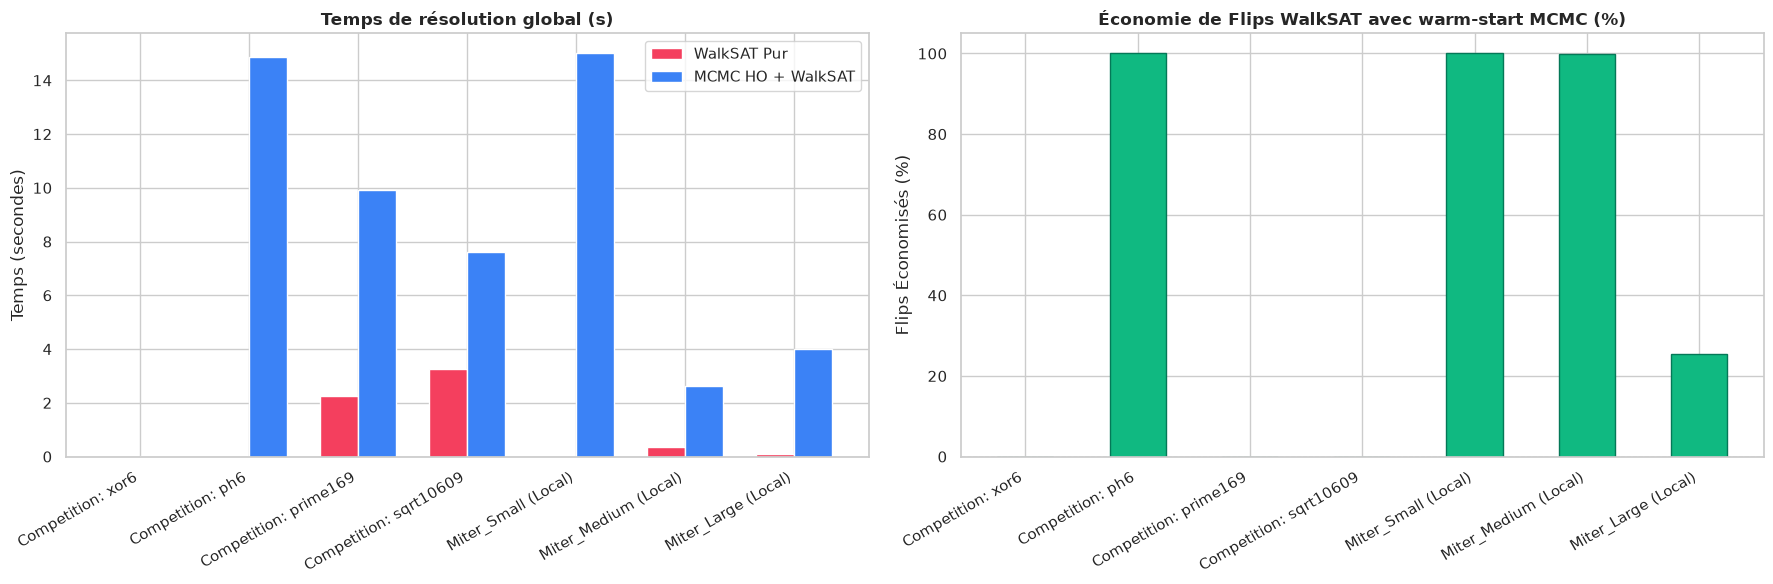

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def run_notebook_evaluation():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device sélectionné pour PyTorch : {device} (GPU disponible : {torch.cuda.is_available()})\n")
    
    # Définition des benchmarks à tester
    benchmarks_to_run = []
    
    # 1. Sélection de fichiers de la SAT Competition (téléchargés automatiquement)
    instances = ["xor6", "ph6", "prime169", "sqrt10609"]
    for key in instances:
        url = COMPETITION_BENCHMARKS[key]
        try:
            print(f"Téléchargement de l'instance Competition : {key}...")
            content = download_benchmark(url)
            n_vars, clauses = parse_dimacs_content(content)
            n_vars_3sat, clauses_3sat = convert_to_3sat(n_vars, clauses)
            benchmarks_to_run.append((f"Competition: {key}", n_vars_3sat, clauses_3sat))
        except Exception as e:
            print(f"  [ERREUR] Impossible de charger {key} ({e}).")
            
    # 2. Ajout de circuits Miters de test (locaux)
    benchmarks_to_run.append(("Miter_Small (Local)", *generate_miter_circuit_3sat(10, 40, "Facile", seed=100)))
    benchmarks_to_run.append(("Miter_Medium (Local)", *generate_miter_circuit_3sat(30, 120, "Moyen", seed=101)))
    benchmarks_to_run.append(("Miter_Large (Local)", *generate_miter_circuit_3sat(60, 250, "Difficile", seed=102)))
    
    results = []
    
    for name, n_vars, clauses in benchmarks_to_run:
        n_clauses = len(clauses)
        print(f"\nEvaluating {name} ({n_vars} variables, {n_clauses} clauses)...\n")
        
        # CDCL
        glu_res, t_glu = solve_with_glucose(n_vars, clauses)
        
        # RC2 (MaxSAT)
        rc2_res, t_rc2, rc2_unsat = solve_maxsat_with_rc2(n_vars, clauses)
        
        # Détermination de l'optimum global à viser
        target_val = rc2_unsat if rc2_unsat >= 0 else (0 if glu_res == "SAT" else 1)
        
        # WalkSAT Pur
        _, pure_unsat, t_pure, flips_pure = run_walksat(None, clauses, n_vars, target_unsat=target_val, max_time=10.0)
        
        # MCMC HO Seul
        ho_spins, t_ho, ho_unsat = solve_3sat_mcmc_higher_order(n_vars, clauses, max_sweeps=150, verbose=False, device=device)
        
        # MCMC HO + WalkSAT
        _, ho_walk_unsat, t_ho_walk, flips_ho_walk = run_walksat(ho_spins, clauses, n_vars, target_unsat=target_val, max_time=10.0)
        t_total_ho_walk = t_ho + t_ho_walk
        
        # Calcul du gain en flips
        flips_saved_pct = 0.0
        if flips_pure > 0:
            flips_saved_pct = ((flips_pure - flips_ho_walk) / flips_pure) * 100.0
            
        results.append({
            "Instance": name,
            "Variables": n_vars,
            "Clauses": n_clauses,
            "Glucose": glu_res,
            "Glucose Time (s)": t_glu,
            "RC2 Unsat (Opt)": rc2_unsat,
            "WalkSAT Pur Time (s)": t_pure,
            "WalkSAT Pur Flips": flips_pure,
            "MCMC HO Unsat": ho_unsat,
            "MCMC HO Time (s)": t_ho,
            "MCMC HO+WalkSAT Time (s)": t_total_ho_walk,
            "MCMC HO+WalkSAT Flips": flips_ho_walk,
            "Flips Saved (%)": flips_saved_pct
        })
        
    df = pd.DataFrame(results)
    
    # Affichage du tableau formaté sous forme de dégradé thermique
    print("\n=== TABLEAU DE SYNTHÈSE DES PERFORMANCES ===")
    display(df.style.background_gradient(subset=["Flips Saved (%)"], cmap="RdYlGn")
                    .format({"Glucose Time (s)": "{:.4f}", 
                             "WalkSAT Pur Time (s)": "{:.4f}",
                             "MCMC HO Time (s)": "{:.4f}",
                             "MCMC HO+WalkSAT Time (s)": "{:.4f}",
                             "Flips Saved (%)": "{:.1f}%"}))
    
    # Tracé des visualisations
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), dpi=100)
    
    # Graphique 1 : Comparaison de temps
    x = np.arange(len(df))
    width = 0.35
    ax1.bar(x - width/2, df["WalkSAT Pur Time (s)"], width, label="WalkSAT Pur", color="#f43f5e")
    ax1.bar(x + width/2, df["MCMC HO+WalkSAT Time (s)"], width, label="MCMC HO + WalkSAT", color="#3b82f6")
    ax1.set_title("Temps de résolution global (s)", fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels(df["Instance"], rotation=30, ha="right")
    ax1.set_ylabel("Temps (secondes)")
    ax1.legend()
    
    # Graphique 2 : Flips sauvés (%)
    ax2.bar(x, df["Flips Saved (%)"], color="#10b981", edgecolor="#047857", width=0.5)
    ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax2.set_title("Économie de Flips WalkSAT avec warm-start MCMC (%)", fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(df["Instance"], rotation=30, ha="right")
    ax2.set_ylabel("Flips Économisés (%)")
    
    plt.tight_layout()
    plt.show()

run_notebook_evaluation()